## installations

In [1]:
%pip install scikit-learn numpy pandas matplotlib seaborn xgboost
%pip install python-dotenv

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


## necessary importations

In [2]:
from dotenv import load_dotenv
import os

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as panda

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import BaggingClassifier

from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score

import pickle

## Define general variables

In [3]:
# .env variables
load_dotenv()
farine_dataset_filepath = os.getenv("FARINE_DATASET_FILEPATH")
farine_model_filepath = os.getenv("FARINE_MODEL_FILEPATH")

# dataset dataframe
farine_df = panda.DataFrame(panda.read_csv(farine_dataset_filepath))

## visualize dataframe

In [4]:
farine_df

,salubrite_salle,aw,biofilm_surface,temperature_stockage,humidite,oxygene,risk
0,0,0.67,0,26,76,1,1
1,1,0.70,0,19,49,0,1
2,1,0.54,0,12,50,0,0
3,1,0.61,1,33,69,0,1
4,2,0.60,0,12,32,0,0
...,...,...,...,...,...,...,...
9995,1,0.55,0,32,60,0,0
9996,1,0.77,1,12,31,1,1
9997,1,0.60,0,19,59,0,0
9998,1,0.42,0,11,46,0,0


## prepare training and test data

In [5]:
# split features from target
X =farine_df.drop('risk', axis=1)
y =farine_df['risk']

# split to ttaining and testing data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# normalize each data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## define a training and testing function

In [6]:
def test_model(model):

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    print(f"=== performances of {model} ===")

    accuracy = accuracy_score(y_test, y_pred)
    print("Accuracy:", accuracy)
    print()

    precision = precision_score(y_test,y_pred, average="micro")
    print(f"Precision score:", precision)
    print()

    recall = recall_score(y_test, y_pred, average='micro')
    print(f"Recall score:", recall)
    print()

    print("confusion matrix:")
    matrix = confusion_matrix(y_test, y_pred)
    sns.heatmap(matrix, annot=True, cmap='Blues')

    return model

## train different models


### XGBClassifier

Text(0, 0.5, 'Accuracy Score')

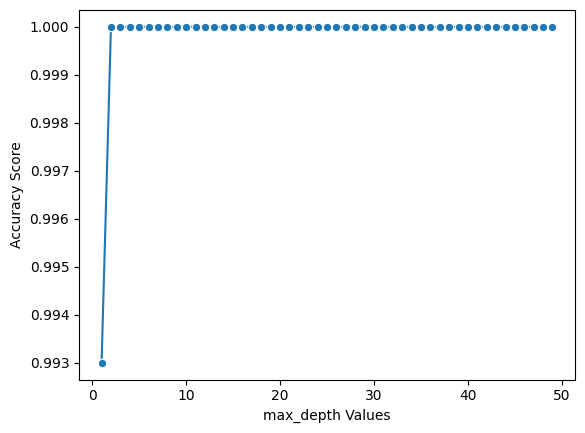

In [7]:
# best parameters
max_values = [i for i in range(1,50)]
scores = []

for maximum in max_values:
    xgb_model = XGBClassifier(max_depth=maximum, n_estimators=100)
    score = cross_val_score(xgb_model, X, y, cv=5)
    scores.append(np.mean(score))
    
sns.lineplot(x = max_values, y = scores, marker = 'o')
plt.xlabel("max_depth Values")
plt.ylabel("Accuracy Score")

=== performances of XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, ...) ===
Accuracy: 1.0

Precision score: 1.0

Recall score: 1.0

confusion matrix:


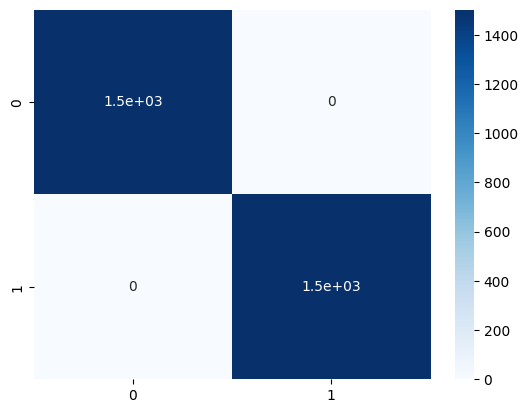

In [9]:
xgb_model = XGBClassifier(max_depth=5, n_estimators=100)

xgb_model = test_model(xgb_model)

### linear svc

Text(0, 0.5, 'Accuracy Score')

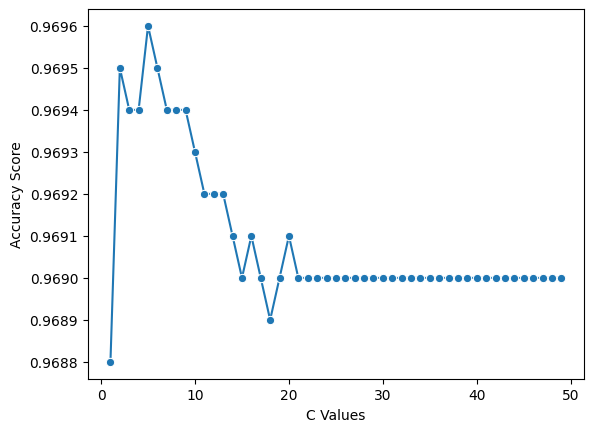

In [8]:
# best parameters
max_values = [i for i in range(1,50)]
scores = []

for maximum in max_values:
    lsvc_model = LinearSVC(C=maximum)
    score = cross_val_score(lsvc_model, X, y, cv=5)
    scores.append(np.mean(score))
    
sns.lineplot(x = max_values, y = scores, marker = 'o')
plt.xlabel("C Values")
plt.ylabel("Accuracy Score")

=== performances of LinearSVC(C=35) ===
Accuracy: 0.819

Precision score: 0.819

Recall score: 0.819

confusion matrix:


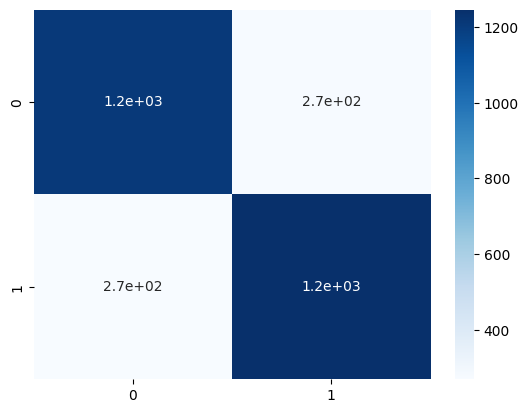

In [15]:
lsvc_model = LinearSVC(C=35)

lsvc_model = test_model(lsvc_model)

### random forest

Text(0, 0.5, 'Accuracy Score')

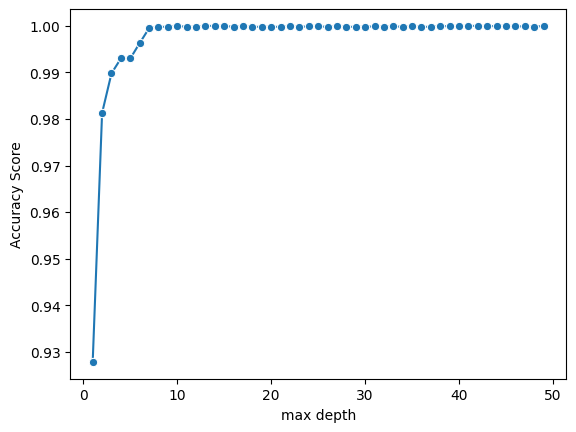

In [10]:
# best parameters
max_values = [i for i in range(1,50)]
scores = []

for maximum in max_values:
    random_forest_model = RandomForestClassifier(max_depth=maximum)
    score = cross_val_score(random_forest_model, X, y, cv=5)
    scores.append(np.mean(score))
    
sns.lineplot(x = max_values, y = scores, marker = 'o')
plt.xlabel("max depth")
plt.ylabel("Accuracy Score")

=== performances of RandomForestClassifier(max_depth=10) ===
Accuracy: 0.9993333333333333

Precision score: 0.9993333333333333

Recall score: 0.9993333333333333

confusion matrix:


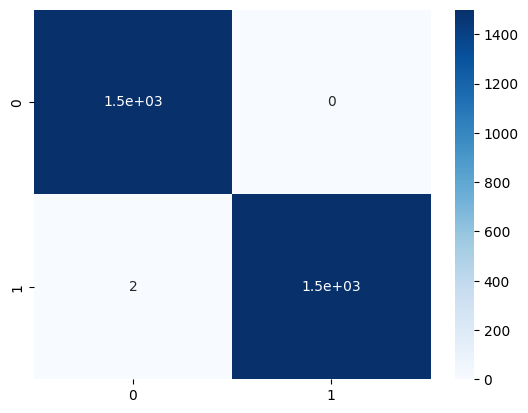

In [11]:
random_forest_model = RandomForestClassifier(max_depth=10)

random_forest_model = test_model(random_forest_model)

## Try a BaggingClassifier of the best models

### XGBoost

In [ ]:
# # best parameters
# max_values = [i for i in range(1,50)]
# scores = []
# classifier = XGBClassifier(max_depth=5, n_estimators=100)

# for maximum in max_values:
#     bagging_clf = BaggingClassifier(estimator=classifier, n_estimators = maximum, random_state = 42)
#     score = cross_val_score(bagging_clf, X, y, cv=5)
#     scores.append(np.mean(score))
    
# sns.lineplot(x = max_values, y = scores, marker = 'o')
# plt.xlabel("n_estimators")
# plt.ylabel("Accuracy Score")

## Save model to pickle file

In [12]:
with open(farine_model_filepath, "wb") as f:
    pickle.dump(xgb_model, f)